In [ ]:
# необходимые библиотеки для воспроизведения
#!pip install matplotlib==3.10.8 numpy==2.3.5 optuna==4.7.0 pandas==3.0.0 seaborn==0.13.2 scikit-learn==1.8.0 transformers==5.2.0 

In [ ]:
# необходимые библиотеки для воспроизведения
#pip install torch==2.9.0 torchvision==0.24.0 torchaudio==2.9.0 --index-url https://download.pytorch.org/whl/cu130

# Поиск фото по описанию

Для фотохостинга профессиональных фотографов «Со Смыслом» (“With Sense”) разработать функционал по поиску референсных (на основе тесктового описания) фотографий для фотографов.

Для демонтсрационной версии необходимо разработать модель, которая на основании векторного представления изображения и векторного представление текста на выходе выдаст число от 0 до 1 — и покажет, насколько текст и картинка подходят друг другу.

Также необходимо очистить данные от описаний и изображений детей (ребёнком считается любой человек, не достигший 16-ти лет)

Работа над проектом будет выполняться в несколько этапов:
- загрузка и изучение общей информации о данных;
- предобработка данных;
- исследовательский анализ данных;
- подготовка данных для модели МО;
- инициализации и обучению моделей МО с различными гиперпараметрами 

**Описание данных**
1. В файле `train_dataset.csv` находится информация, необходимая для обучения:
    - имя файла изображения;
    - идентификатор описания;
    - текст описания (для одной картинки может быть доступно до 5 описаний).
2. В папке `train_images` содержатся изображения для тренировки модели
3. В файле `CrowdAnnotations.tsv`  — данные по соответствию изображения и описания, полученные с помощью краудсорсинга:
    - имя файла изображения;
    - идентификатор описания;
    - доля людей, подтвердивших, что описание соответствует изображению;
    - количество человек, подтвердивших, что описание соответствует изображению;
    - количество человек, подтвердивших, что описание не соответствует изображению.
4. В файле `ExpertAnnotations.tsv`  — данные по соответствию изображения и описания, полученные в результате опроса экспертов^
    - имя файла изображения;
    - идентификатор описания;
    - оценки трёх экспертов.
5. В файле `test_queries.csv` находится информация, необходимая для тестирования:
    - идентификатор запроса;
    - текст запроса;
    - релевантное изображение.

In [1]:
import os
import re
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from tqdm import notebook, tqdm
from transformers import AutoTokenizer, AutoModel

In [2]:
# скрытие пердупреждений
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
pd.set_option('display.max_colwidth', None)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
RANDOM_STATE=42

## Загрузка данных

In [6]:
train_dataset = pd.read_csv('data/train_dataset.csv')
crowd_annotations = pd.read_csv('data/CrowdAnnotations.tsv', sep='\t', header=None) 
expert_annotations = pd.read_csv('data/ExpertAnnotations.tsv', sep='\t', header=None) 

In [7]:
train_dataset.head()

,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .


In [8]:
train_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   image       5822 non-null   str  
 1   query_id    5822 non-null   str  
 2   query_text  5822 non-null   str  
dtypes: str(3)
memory usage: 136.6 KB


In [9]:
# количество уникальных изображеий и текстов
train_dataset[['image', 'query_id']].nunique()

image       1000
query_id     977
dtype: int64

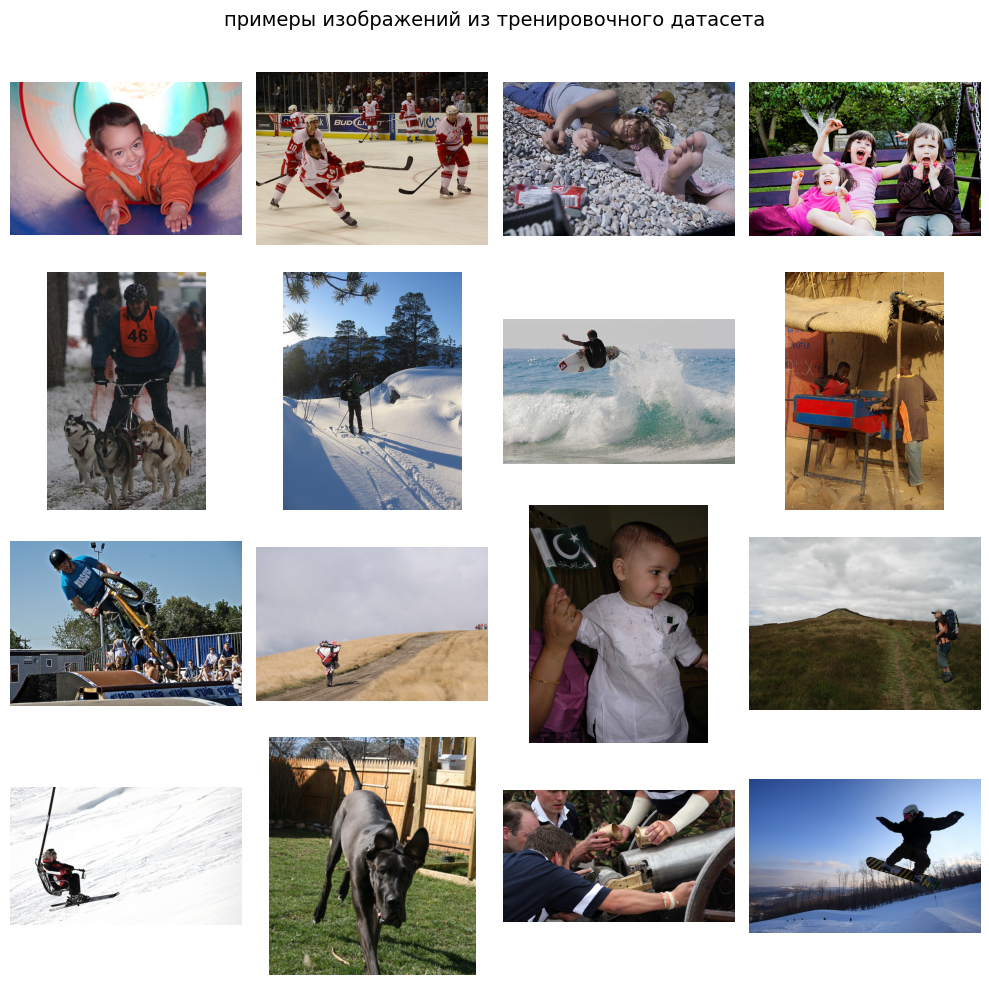

In [10]:
# вывод изображений на экран
image_folder = 'data/train_images'
sample_images = train_dataset.sample(16, random_state=RANDOM_STATE)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('примеры изображений из тренировочного датасета', fontsize=14)

for idx, (_, row) in enumerate(sample_images.iterrows()):
    ax = axes[idx // 4, idx % 4]
    img = Image.open(os.path.join(image_folder, row['image']))
    ax.imshow(img)
#    ax.set_title(f"{row['query_text']}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [11]:
crowd_annotations.head()

,0,1,2,3,4
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,0.0,0,3
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,0.0,0,3


In [12]:
crowd_annotations.info()

<class 'pandas.DataFrame'>
RangeIndex: 47830 entries, 0 to 47829
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       47830 non-null  str    
 1   1       47830 non-null  str    
 2   2       47830 non-null  float64
 3   3       47830 non-null  int64  
 4   4       47830 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 1.8 MB


In [13]:
expert_annotations.head()

,0,1,2,3,4
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2


In [14]:
expert_annotations.info()

<class 'pandas.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       5822 non-null   str  
 1   1       5822 non-null   str  
 2   2       5822 non-null   int64
 3   3       5822 non-null   int64
 4   4       5822 non-null   int64
dtypes: int64(3), str(2)
memory usage: 227.6 KB


<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

- На этапе изучения общей информации, в данных не обнаружено пропусков, возможно, присутствуют дубликаты (будут выявлены на следующем этапе).

- В тренировочном датасете 1000 уникальных изображений и 977 уникальных тестов

## Предобработка данных

На данном этапе будет проведена работа по: 
1. агрегации оценок соответствия текста и изображения в датафрейме expert_annotations и визуализация распределения количества оценок;
2. присоединию к `train_dataset` агрегированных оценок экспертов и доле людей, подтвердивших, что описание соответствует изображению:
     - присоединениие проведем на основании результатов проверки наличия пар наименование изображения - идентификатор описания из таблицы `train_dataset` в `expert_annotations` и`crowd_annotations`
3. выделению целевой переменной на основании присоединенных значений

### Агрегация оценок датафрейма expert_annotations

In [15]:
# агрегация оценок на основе медианного значения оценок 3-х экспертов
expert_annotations['aggregated_assessment'] = expert_annotations[[2, 3, 4]].median(axis=1).astype(int)
expert_annotations.head()

,0,1,2,3,4,aggregated_assessment
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2,1
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2,1
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2,2
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2,1


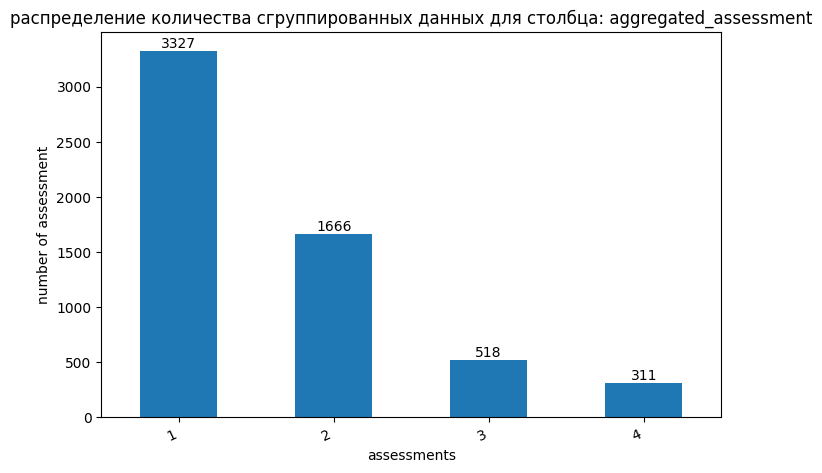

In [16]:
# график распределения количества оценок
ax = expert_annotations.groupby('aggregated_assessment')['aggregated_assessment'].count() \
    .sort_values(ascending=False).plot(kind='bar',
                                       xlabel='assessments', 
                                       ylabel='number of assessment',
                                       figsize=(8, 5),
                                       width=0.5)

# настройка графика
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.set_title(f'распределение количества сгруппированных данных для столбца: {'aggregated_assessment'}')
for bar_group in ax.containers:
     ax.bar_label(bar_group, label_type='edge')

По результатам визуализации распределения количества агренированных оценок экспертов установлено, что:
- в 57% случаев изображение и запрос совершенно не соответствуют друг другу (оценка 1);
- в 29% случаев запрос содержит элементы описания изображения, но в целом запрос тексту не соответствует (оценка 2);
- в 9% случаев запрос и текст соответствуют с точностью до некоторых деталей (оценка 3);
- в 5% случаев запрос и текст соответствуют полностью (оценка 4)

### Объединение таблиц

Проведем присоединение к таблице train_dataset агрегированных оценок экспертов (таблица expert_annotations) и доле людей, подтвердивших, что описание соответствует изображению (таблица crowd_annotations) на основании пары наименование изображения - идентификатор описания

\
Перед объединением проверим все ли пары (на основании которых будет проведено присоединение) присутствуют в датафреймах expert_annotations и crowd_annotations

In [17]:
# множества пар из таблиц
train_pairs = set(zip(train_dataset['image'], train_dataset['query_id']))
expert_pairs = set(zip(expert_annotations[0], expert_annotations[1]))
crowd_pairs = set(zip(crowd_annotations[0], crowd_annotations[1]))

# проверка наличия пар: наименование изображения - идентификатор описания
# из train_dataset в expert_annotations
missing_in_expert = train_pairs - expert_pairs
print(f"количество пар из train_dataset, отсутствующих в expert_annotations: {len(missing_in_expert)}")

# проверка наличия пар наименование изображения - идентификатор описания
# из train_dataset в crowd_annotations
missing_in_crowd = train_pairs - crowd_pairs
print(f"количество пар из train_dataset, отсутствующих в crowd_annotations: {len(missing_in_crowd)}")


количество пар из train_dataset, отсутствующих в expert_annotations: 0
количество пар из train_dataset, отсутствующих в crowd_annotations: 3493


\
В таблице crowd_annotations отсутствует 3493 пары наименование изображения - идентификатор описания из таблицы train_dataset, поэтому проведем присоединение только агрегированных оценок экспертов (учет только оценок экспертов может улучшить качество обучения, т.к оценки экспертов более точные нежели краудсорсинговые)

In [18]:
# присоединение к train_dataset агрегированных оценок экспертов
train_dataset_combined = train_dataset.merge(
    expert_annotations[[0, 1, 'aggregated_assessment']],
    left_on=['image', 'query_id'],
    right_on=[0, 1],
    how='left'
).drop(columns=[0, 1])

train_dataset_combined.head()

,image,query_id,query_text,aggregated_assessment
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,1
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,1
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,2
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,4
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,1


In [19]:
train_dataset_combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   image                  5822 non-null   str  
 1   query_id               5822 non-null   str  
 2   query_text             5822 non-null   str  
 3   aggregated_assessment  5822 non-null   int64
dtypes: int64(1), str(3)
memory usage: 182.1 KB


### Выделение целевой переменной

Приведем агрегированные значения оценок в диапазон от о до 1 путем минимаксной нормализации.

In [20]:
# получение целевой переменной
train_dataset_combined['target'] = ((train_dataset_combined['aggregated_assessment'] - 1) / (4 - 1)).round(2)

# удаления столбца с агрегированными оценками
train_dataset_combined = train_dataset_combined.drop('aggregated_assessment', axis=1)

In [21]:
train_dataset_combined.head()

,image,query_id,query_text,target
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,0.00
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,0.00
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,0.33
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,1.00
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,0.00


### Выводы

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

1. Проведена работа по агрегации оценок экспертов соответствия текста и изображения в датафрейме `expert_annotations` и визуализация полученных результатов.
2. По результатам визуализации распределения количества агренированных оценок экспертов установлено, что:
    - в 57% случаев изображение и запрос совершенно не соответствуют друг другу (оценка 1);
    - в 29% случаев запрос содержит элементы описания изображения, но в целом запрос тексту не соответствует (оценка 2);
    - в 9% случаев запрос и текст соответствуют с точностью до некоторых деталей (оценка 3);
    - в 5% случаев запрос и текст соответствуют полностью (оценка 4).
    - выявленный дисбаланс, вероятно, повлияет на обучение модели в худшую сторону
3. Установлено, что таблице `crowd_annotations` отсутствует 3493 пары *наименование изображения - идентификатор описания* из таблицы `train_dataset`. Основываясь на данном результате выделение целевой переменной будет проведено только исходя из агрегированных оценок экспертов путем присоединения к таблице `train_dataset` данных оценок (таблица `expert_annotations`) на комбинаций вышеуказанных пар (что может улучшить качество обучения, т.к оценки экспертов более точные нежели краудсорсинговые).
4. Проведено преобразование значений присоединенных оценок в диапазон от о до 1 путем минимаксной нормализации.

В результате получена таблица `train_dataset_combined` со следующими столбцами:
- имя файла изображения;
- идентификатор описания;
- текст описания;
- целевая переменная.

## Подготовка данных для модели МО

На данном этапе будет проведена работа по: 
1. очистке данных, в соответствии с юридическими ограничениями:
    - проведем очитку данных от лишних симоволов с использованием регулярных выражений;
    - составим список слов, которые могут попадать под юр. ограничения
    - исключим из таблицы `train_dataset_combined` от описаний и изображений детей (ребёнком считается любой человек, не достигший 16-ти лет).
2. векторизации текстовых описаний изображений:
    - инициализации токенизатора модели (в качестве модели используем BERT_base);
    - преобразованию тестов в номера токенов
    - преобразованию получившихся векторов в эмбеддинги и переводу их в матрицу признаков;
3. векторизации изображений:
   - проведем загрузку изображений с использованием библиотеки PIL;
   - векторизацию проведем с использованием модели ResNet50.
4. разделению данных на тренировочную и валидационную выборки

### Очистка данных

In [22]:
# функция очистки данных
def clean_text(text):
    '''
    функция для:
    - приведения текстов к нижнему регистру;
    - удаления цифр
    '''   
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s\.\,\!\?\(\)\']', ' ', text)

    # удаление множественных пробелов
    text = re.sub(r'\s+', ' ', text).strip()

    # удаление пробелов перед точками
    text = re.sub(r'\s+\.', '.', text)

    return text

In [23]:
train_dataset_combined['cleaned_text'] = train_dataset_combined['query_text'].apply(clean_text)

# удаление стобца text
train_dataset_combined = train_dataset_combined.drop('query_text', axis=1)

train_dataset_combined.head()

,image,query_id,target,cleaned_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,0.00,a young child is wearing blue goggles and sitting in a float in a pool.
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,0.00,a young child is wearing blue goggles and sitting in a float in a pool.
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,0.33,a young child is wearing blue goggles and sitting in a float in a pool.
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,1.00,a young child is wearing blue goggles and sitting in a float in a pool.
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,0.00,a young child is wearing blue goggles and sitting in a float in a pool.


In [24]:
# список слов, попадающих под юр. ограничения
words = ['child', 'children', 'kid', 'kids', 'baby', 
         'little', 'small', 'young', 'tiny', 'schoolboy', 
         'schoolgirl', 'preschool', 'teen', 'teenager', 'youth', 
         'sandbox', 'toy', 'kindergarten', 'school', 'classroom',
         'boy', 'boys', 'girl', 'girls']

In [25]:
# преобразование списка слов в регулярное выражение
words_pattern = r'\b(' + '|'.join(words) + r')\b'

In [26]:
# маска для исключения строк, содержащих слова к исключению
mask_contains_words = train_dataset_combined['cleaned_text'].str.contains(
    words_pattern, case=False, regex=True, na=False
)

In [27]:
# фильтрация данных (исключаем строки, содержащие исключаемые слова)
train_dataset_filtered = train_dataset_combined[~mask_contains_words].reset_index(drop=True)

# Проверка
print(f"исходное количество строк: {len(train_dataset_combined)}")
print(f"удалено строк с упоминанием детей: {mask_contains_words.sum()}")
print(f"осталось строк: {len(train_dataset_filtered)}")

исходное количество строк: 5822
удалено строк с упоминанием детей: 1806
осталось строк: 4016


In [28]:
train_dataset_filtered.head()

,image,query_id,target,cleaned_text
0,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,0.00,a man sleeps under a blanket on a city street.
1,3187395715_f2940c2b72.jpg,3181701312_70a379ab6e.jpg#2,0.33,a man sleeps under a blanket on a city street.
2,463978865_c87c6ca84c.jpg,3181701312_70a379ab6e.jpg#2,0.33,a man sleeps under a blanket on a city street.
3,488590040_35a3e96c89.jpg,3181701312_70a379ab6e.jpg#2,0.33,a man sleeps under a blanket on a city street.
4,534875358_6ea30d3091.jpg,3181701312_70a379ab6e.jpg#2,0.00,a man sleeps under a blanket on a city street.


In [29]:
# проверка на дубликаты 
train_dataset_filtered.duplicated().sum()

np.int64(0)

### Векторизации текстовых описаний изображений

In [30]:
# путь к модели
model_path = '../../../models/BERT_base'

# инициализация токенизатора
tokenizer = AutoTokenizer.from_pretrained(model_path)

# инициализация модели
bert_model = AutoModel.from_pretrained(model_path)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ../../../models/BERT_base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [31]:
# преобразование текста в номера токенов
tokenized = train_dataset_filtered['cleaned_text'].apply(
    lambda x: tokenizer.encode(x, add_special_tokens=True, truncation=True)
)

In [32]:
# макс. длина вектора
max_length = tokenized.apply(len).max()
print(f"максимальная длина вектора токенов: {max_length}")

# векторы с отступами
padded = np.array([i + [0] * (max_length - len(i)) for i in tokenized.values])

# маска внимания
attention_mask = np.where(padded != 0, 1, 0)
attention_mask.shape

максимальная длина вектора токенов: 33


(4016, 33)

In [33]:
# предподготовка данных как тензоров
padded_tensor = torch.LongTensor(padded)
attention_mask_tensor = torch.LongTensor(attention_mask)

# перевод модели с CPU на GPU
if torch.cuda.is_available():
    padded_tensor = padded_tensor.cuda()
    attention_mask_tensor = attention_mask_tensor.cuda()
    bert_model = bert_model.cuda()

# преобразование текстов в эмбеддинги
batch_size = 100
text_embeddings = []

with torch.no_grad():
    for i in tqdm(range(0, len(padded_tensor), batch_size)):
        batch = padded_tensor[i:i+batch_size]
        batch_mask = attention_mask_tensor[i:i+batch_size]

        outputs = bert_model(batch, attention_mask=batch_mask)
        last_hidden = outputs.last_hidden_state

        mask_expanded = batch_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        last_hidden_masked = last_hidden * mask_expanded
        
        pooled = torch.max(last_hidden_masked, dim=1)[0]
        text_embeddings.append(pooled.cpu().numpy())
text_embeddings = np.vstack(text_embeddings)

100%|███████████████████████████████████████████████████████████████████████████████████| 41/41 [00:03<00:00, 12.84it/s]


### Векторизации изображений

In [34]:
# загрузка предобученной модели ResNet50
weights = ResNet50_Weights.DEFAULT
resnet_model = resnet50(weights=weights)

# перевод модели в режим предсказания
resnet_model.eval()

# удаление последнего слоя
resnet_model = torch.nn.Sequential(*list(resnet_model.children())[:-1])

# перевод модели на GPU
resnet_model = resnet_model.to(device)

In [35]:
# предобработка изображений
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [36]:
def load_and_transform_image(image_path):
    '''
    функция для загрузки и предобработки изображения
    '''
    image = Image.open(image_path).convert('RGB')
    image_tensor = preprocess(image).unsqueeze(0) 
    return image_tensor.to(device)

In [37]:
# путь к папке с изображениями
image_folder = 'data/train_images'

# наименования изображений
image_names = train_dataset_filtered['image']

# список для хранения эмбеддингов изображений
image_embeddings = []


In [38]:
# преобразование изображений в эмбеддинги
batch_size = 64

for i in tqdm(range(0, len(image_names), batch_size)):
    batch_images = []
    batch_names = image_names[i:i+batch_size]
    
    for img_name in batch_names:
        img_path = os.path.join(image_folder, img_name)
        img_tensor = load_and_transform_image(img_path)
        if img_tensor is not None:
            batch_images.append(img_tensor)
    
    batch_tensor = torch.cat(batch_images, dim=0)

    with torch.no_grad():
        embeddings = resnet_model(batch_tensor)
        embeddings = embeddings.view(embeddings.size(0), -1)
        image_embeddings.append(embeddings.cpu().numpy())

image_embeddings = np.vstack(image_embeddings)    

100%|███████████████████████████████████████████████████████████████████████████████████| 63/63 [00:36<00:00,  1.71it/s]


In [39]:
# cохранение результатов вместе с текстовыми эмбеддингами
joblib.dump({
    'image' : train_dataset_filtered['image'].values,
    'query_id' : train_dataset_filtered['query_id'].values,
    'cleaned_text' : train_dataset_filtered['cleaned_text'].values,
    'text_embeddings': text_embeddings,
    'image_embeddings' : image_embeddings,
    'target': train_dataset_filtered['target'].values
}, 'text_image_embeddings.joblib', compress=0)

['text_image_embeddings.joblib']

In [40]:
print(f"количество пар текст-изображение : {len(image_embeddings)}")
print(f"размерность текстовых эмбеддингов: {text_embeddings.shape}")
print(f"размерность эмбеддингов изображений: {image_embeddings.shape}")

количество пар текст-изображение : 4016
размерность текстовых эмбеддингов: (4016, 768)
размерность эмбеддингов изображений: (4016, 2048)


### Разделение данных на тренировочную и валидационную выборки

Разделение данных на тренировочную и валидационную выборки проведем так, чтобы уникальные тексты не попадали сразу в две выборками.\
Разделим данные в соотношении 90:10

In [41]:
data = joblib.load('text_image_embeddings.joblib')

# уникальные идентификаторы текстов
unique_query_id = np.unique(data['query_id'])

In [42]:
# разделение по уникалтным query_id 
train_query_id, val_query_id = train_test_split(
    unique_query_id,
    test_size=0.1,
    random_state=RANDOM_STATE,
    shuffle=True
)

In [43]:
# маски для фильтрации
train_mask = np.isin(data['query_id'], train_query_id)
val_mask = np.isin(data['query_id'], val_query_id)

In [44]:
X = np.hstack([data['text_embeddings'], data['image_embeddings']])
y = data['target']

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

In [45]:
print(f"количество уникальных текстов: {len(unique_query_id)}")
print(f"количество текстов в тренировочной выборке: {len(train_query_id)}")
print(f"количество текстов в валидационной выборке: {len(val_query_id)}")
print(f"размер обучающей выборки: {X_train.shape}")
print(f"размер валидационной выборки: {X_val.shape}")

количество уникальных текстов: 646
количество текстов в тренировочной выборке: 581
количество текстов в валидационной выборке: 65
размер обучающей выборки: (3573, 2816)
размер валидационной выборки: (443, 2816)


In [46]:
y_train.shape, y_val.shape

((3573,), (443,))

### Выводы

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

По результатам подготовки данных:
1. проведена очистка данных, в соответствии с юридическими ограничениями:
    - проведена очистка данных с использованием регулярных выражений
    - из таблицы `train_dataset_combined` исключено 1806 строк, содержащих описание и наименование изображений детей (ребёнком считается любой человек, не достигший 16-ти лет);
    - в результате получен очищенный датафрейм `train_dataset_filtered`, не содержащий дубликатов.
2. проведена векторизация текстов с использованием модели BERT-base:
    - инициализирован токенизатор;
    - тесты преобразованы в номера токенов (векторы токенов);
    - получившиеся вектора преобразованы в эмбеддинги.
3. проведена векторизация изображений с использованием предобученной модели ResNet50:
	- проведена загрузка изображений с использованием библиотеки PIL;
	- перед преобразованием изображений в эмбеддинги проведена их предобработка для использования модели обученной на датасете  ImageNet.
4. По результатам векторизации текстов и изображений получены эмбеддинги с размерностью:
	- (4503, 768) для тестовых эмбеддингов (4503 - количество пар текст-изображение в `train_dataset_filtered`, 768 - размерность текстовых векторов);
	 - (4503, 2048) для эмбеддингов изображений (4503 - количество пар текст-изображение в `train_dataset_filtered`, 2048 – размер визуальных векторов, выход с последнего сверточного слоя ResNet50)
5. проведено разделение данных на тренировочную и валидационную выборки в соотношении 90:10. Данные разделены так чтобы уникальные query_id	не попадали сразу в две выборки.


## Обучение моделей МО

- На данном этапе будет проведена работа по инициализации и обучению моделей МО с различными гиперпараметрами.\
Используем модели: Ridge, Lasso, ElasticNet, LinearRegression и полносвязную нейросеть;
- Подбор наилучших гиперпараметров будем производить на основании значения метрики при кроссвалидации с помощью библиотеки optuna;
- В качесте основной метрики используем MSE.

In [47]:
# скрытие сообщений (кроме ошибок)
optuna.logging.set_verbosity(optuna.logging.CRITICAL)

In [49]:
# функция подбора гиперпараметров
def objective(trial, model_name, X_train, y_train, X_val=None, y_val=None):
    '''
    функция подбора гиперпараметров для: 
    - моделей для моделей регрессии (Ridge, Lasso, ElasticNet, LinearRegression);
    - полносвязной нейросети
    на основании значения метрики MSE при короссвалидации
    '''
    # линейные модели
    if model_name in ['ridge', 'lasso', 'elastic', 'lr']:
        
        # общие параметры
        common_params = {
            'random_state': RANDOM_STATE,
            'max_iter': 2000
        }
        
        # гиперпараметры для Ridge
        if model_name == 'ridge':
            params = {
                'alpha': trial.suggest_float('alpha', 1e-3, 5.0, log=True),
                'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'sag'])
            }
            params.update(common_params)
            model = make_pipeline(
                StandardScaler(),
                Ridge(**params)
            )
    
        # гиперпараметры для Lasso
        elif model_name == 'lasso':
            params = {
                'alpha': trial.suggest_float('alpha', 1e-4, 5.0, log=True), 
                'selection': trial.suggest_categorical('selection', ['cyclic', 'random'])
            }
            params.update(common_params)
            model = make_pipeline(
                StandardScaler(),
                Lasso(**params))
    
        # гиперпараметры для ElasticNet
        elif model_name == 'elastic':
            params = {
                'alpha': trial.suggest_float('alpha', 1e-4, 10.0, log=True),  
                'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),  
                'selection': trial.suggest_categorical('selection', ['cyclic', 'random'])
            }
            params.update(common_params)
            model = make_pipeline(
                StandardScaler(),
                ElasticNet(**params))
        
        # игициализация LinearRegression
        elif model_name == 'lr':
            model = make_pipeline(
                StandardScaler(),
                LinearRegression())
            
        
        # метрики
        scoring = {
            'mse': 'neg_mean_squared_error',
            'mae': 'neg_mean_absolute_error',
            'r2': 'r2'
        }

        # кроссвалидация
        cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_validate(model, X_train, y_train, cv=cv, 
                                scoring=scoring, n_jobs=-1, return_train_score=False)
    
        
        # переобразование отрицательных MSE в положительные
        mse_scores = -scores['test_mse']
        mae_scores = -scores['test_mae']
        r2_scores = scores['test_r2']
        
        # среднее значение метрик
        metrics = {
            'mse' : round(np.mean(mse_scores), 3),
            'mae' : round(np.mean(mae_scores), 3),
            'r2' : round(np.mean(r2_scores), 3)
        }
        # сохранение метрик
        for name, value in metrics.items():
            trial.set_user_attr(name, value)
    
        return metrics['mse']

    # полносвязная нейросеть
    elif model_name == 'neural_network':
        
        # параметры для инициализации и обучений нейросети
        params = {
            # параметры инициализации
            'n_layers': trial.suggest_int('n_layers', 1, 5),  
            'hidden_size': trial.suggest_int('hidden_size', 64, 1024, log=True),  
            'dropout': trial.suggest_float('dropout', 0.0, 0.5),  
            'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'sigmoid']),  
            
            # параметры обучения
            'batch_size': trial.suggest_categorical('batch_size', [64, 128, 256]),
            'learning_rate': trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True),
            'optimizer': trial.suggest_categorical('optimizer', ['adam', 'adamw', 'sgd']),
            'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
            'epochs': trial.suggest_int('epochs', 10, 400)
            }

        n_in_neurons = X_train.shape[1]
        model = FeedForwardNN(
            n_in_neurons=n_in_neurons,
            n_out_neurons=1,
            n_layers=params['n_layers'],
            hidden_size=params['hidden_size'],
            dropout=params['dropout'],
            activation=params['activation']
        ).to(device)

        # обучение с валидацией
        val_mse, val_mae, val_r2 = training(model, X_train, y_train, 
                                            X_val, y_val, params, 
                                            device)

        trial.set_user_attr('mae', val_mae)
        trial.set_user_attr('r2', val_r2)

        return val_mse

### Обучение Ridge

In [50]:
start = time.time()

study_ridge = optuna.create_study(direction='minimize')
study_ridge.optimize(lambda trial: objective(trial, 'ridge', X_train, y_train), 
                  n_trials=15, show_progress_bar=True)

print(f"время подбора гиперпараметров: {time.time() - start:.2f}\n")
print('лучшие параметры', study_ridge.best_params)
print('\nлучшее значение MSE при кроссвалидации:',
      study_ridge.best_value)

  0%|          | 0/15 [00:00<?, ?it/s]

/home/dmitriy/miniconda3/envs/pytorch_gpu/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.3807920907236166e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/dmitriy/miniconda3/envs/pytorch_gpu/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.348521098762603e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/dmitriy/miniconda3/envs/pytorch_gpu/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.4275475790934706e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/dmitriy/miniconda3/envs/pytorch_gpu/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.941610232123139e-09.

время подбора гиперпараметров: 782.51

лучшие параметры {'alpha': 4.780319578551339, 'solver': 'sag'}

лучшее значение MSE при кроссвалидации: 0.118


In [51]:
# лучшие параметры модели
best_trial_ridge = study_ridge.best_trial

In [52]:
# получаем лучшие параметры
best_params_ridge = study_ridge.best_params

# инициализация модели с лучшими параметрами
best_model_ridge = make_pipeline(
    StandardScaler(),
    Ridge(
        alpha=best_params_ridge['alpha'],
        solver=best_params_ridge['solver'],
        random_state=RANDOM_STATE,
        max_iter=2000
    )
)

# обучение на тренировочных данных
best_model_ridge.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",4.780319578551339
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",2000


In [53]:
# сохранение модели
ridge_model_package = {
    'model': best_model_ridge,
    'best_params': best_params_ridge,
    'best_score': study_ridge.best_value,
    'feature_columns': None, 
    'random_state': RANDOM_STATE,
    'timestamp': time.strftime("%Y-%m-%d %H:%M:%S")
}

joblib.dump(ridge_model_package, 'ridge_model_package.joblib')

['ridge_model_package.joblib']

### Обучение Lasso

In [54]:
start = time.time()

study_lasso = optuna.create_study(direction='minimize')
study_lasso.optimize(lambda trial: objective(trial, 'lasso', X_train, y_train), 
                  n_trials=15, show_progress_bar=True)

print(f"время подбора гиперпараметров: {time.time() - start:.2f}\n")
print('лучшие параметры', study_lasso.best_params)
print('\nлучшее значение MSE при кроссвалидации:',
      study_lasso.best_value)

  0%|          | 0/15 [00:00<?, ?it/s]

время подбора гиперпараметров: 51.52

лучшие параметры {'alpha': 0.008603885186545274, 'selection': 'random'}

лучшее значение MSE при кроссвалидации: 0.071


In [55]:
# лучшие параметры модели
best_trial_lasso = study_lasso.best_trial

In [56]:
# получаем лучшие параметры
best_params_lasso = study_lasso.best_params

# инициализация модели с лучшими параметрами
best_model_lasso = make_pipeline(
    StandardScaler(),
    Lasso(
        alpha=best_params_lasso['alpha'],
        selection=best_params_lasso['selection'],
        random_state=RANDOM_STATE,
        max_iter=2000
    )
)

# обучение на тренировочных данных
best_model_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.008603885186545274
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


In [57]:
# сохранение модели
lasso_model_package = {
    'model': best_model_lasso,
    'best_params': best_params_lasso,
    'best_score': study_lasso.best_value,
    'feature_columns': None, 
    'random_state': RANDOM_STATE,
    'timestamp': time.strftime("%Y-%m-%d %H:%M:%S")
}

joblib.dump(ridge_model_package, 'lasso_model_package.joblib')

['lasso_model_package.joblib']

### Обучение ElasticNet

In [58]:
start = time.time()

study_elastic = optuna.create_study(direction='minimize')
study_elastic.optimize(lambda trial: objective(trial, 'elastic', X_train, y_train), 
                  n_trials=15, show_progress_bar=True)

print(f"время подбора гиперпараметров: {time.time() - start:.2f}\n")
print('лучшие параметры', study_elastic.best_params)
print('\nлучшее значение MSE при кроссвалидации:',
      study_elastic.best_value)

  0%|          | 0/15 [00:00<?, ?it/s]

время подбора гиперпараметров: 45.12

лучшие параметры {'alpha': 0.009495501763790432, 'l1_ratio': 0.489258126710017, 'selection': 'random'}

лучшее значение MSE при кроссвалидации: 0.071


In [59]:
# лучшие параметры модели
best_trial_elastic = study_elastic.best_trial

In [60]:
# Получаем лучшие параметры
best_params = study_elastic.best_params

# инициализация модели с лучшими параметрами
best_model = make_pipeline(
    StandardScaler(),
    ElasticNet(
        alpha=best_params['alpha'],
        l1_ratio=best_params['l1_ratio'],
        selection=best_params['selection'],
        random_state=RANDOM_STATE,
        max_iter=2000
    )
)

# обучение на тренировочных данных
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('elasticnet', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.009495501763790432
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.489258126710017
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False


In [61]:
# сохранение модели
model_package = {
    'model': best_model,
    'best_params': best_params,
    'best_score': study_elastic.best_value,
    'feature_columns': None, 
    'random_state': RANDOM_STATE,
    'timestamp': time.strftime("%Y-%m-%d %H:%M:%S")
}

joblib.dump(model_package, 'elastic_model_package.joblib')

['elastic_model_package.joblib']

In [ ]:
import gc

del study_elastic
gc.collect()

### Обучение LinearRegrission

In [62]:
start = time.time()

study_lr = optuna.create_study(direction='minimize')
study_lr.optimize(lambda trial: objective(trial, 'lr', X_train, y_train), 
                  n_trials=10, show_progress_bar=True)

print(f"время подбора гиперпараметров: {time.time() - start:.2f}\n")
print('лучшие параметры', study_lr.best_params)
print('\nлучшее значение MSE при кроссвалидации:',
      study_lr.best_value)

  0%|          | 0/10 [00:00<?, ?it/s]

время подбора гиперпараметров: 77.68

лучшие параметры {}

лучшее значение MSE при кроссвалидации: 0.124


In [64]:
# лучшие параметры модели
best_trial_lr = study_lr.best_trial

### Инициализация и обучение нейросети

In [65]:
class FeedForwardNN(nn.Module):
    '''
    класс инициализации нейросети
    используемые параметры:
    n_in_neurons - количество нейронов на входном слое
    n_out_neurons - количество нейронов на последнем слое
    n_layers - количество скрытых слоев
    hidden_size - количество нейронов в скрытых слоях
    dropout - регуляризация
    activation - функция активации
    '''
    def __init__(self, n_in_neurons, n_out_neurons, 
               n_layers, hidden_size, 
               dropout, activation):
        super(FeedForwardNN, self).__init__()

        layers = []

        # входной слой
        layers.append(nn.Linear(n_in_neurons, hidden_size))
        layers.append(self.get_activation(activation))
        layers.append(nn.Dropout(dropout))

        # скрытые слои
        for _i in range(n_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(self.get_activation(activation))
            layers.append(nn.Dropout(dropout))

        # выходной слой
        layers.append(nn.Linear(hidden_size, n_out_neurons))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

    # функции активации
    def get_activation(self, activation_name):
        if activation_name == 'relu':
            return nn.ReLU()
        elif activation_name == 'tanh':
            return nn.Tanh()
        elif activation_name == 'sigmoid':
            return nn.Sigmoid()
        else:
            return nn.ReLU()

    def forward(self, x):
        return self.network(x)

In [66]:
def training(model, X_train, y_train, X_val, y_val, params, device):
    '''
    функция обучения нейросети, расчета метрики MSE 
     и подбора оптимальных значений параметров
    '''
    # инициализация датасетов и лоадеров
    train_dataset = TensorDataset(
        torch.FloatTensor(X_train),
        torch.FloatTensor(y_train).view(-1, 1)
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=params['batch_size'],
        shuffle=True
    )

    # обработка оптимизаторов
    if params['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), 
                                     lr=params['learning_rate'],
                                     weight_decay=params['weight_decay'])
    elif params['optimizer'] == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(),
                                      lr=params['learning_rate'],
                                      weight_decay=params['weight_decay'])
    else:
        optimizer = torch.optim.SGD(model.parameters(),
                                    lr=params['learning_rate'],
                                    momentum=0.9,
                                    weight_decay=params['weight_decay'])

    # функция потерь
    loss = nn.MSELoss()

    # обучение нейросети
    model.train()
    for epoch in range(params['epochs']):
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            y_train_pred = model(batch_X)
            loss_value = loss(y_train_pred, batch_y)
            loss_value.backward()
            optimizer.step()

    # вычисление метрик на валидации
    model.eval()
    with torch.no_grad():
        val_X = torch.FloatTensor(X_val).to(device)
        val_y = torch.FloatTensor(y_val).view(-1, 1).to(device)
        val_y_pred = model(val_X)
        val_loss_value = loss(val_y_pred, val_y).item()

        val_y_np = val_y.cpu().numpy()
        val_y_pred_np = val_y_pred.cpu().numpy()
        val_mae = mean_absolute_error(val_y_np, val_y_pred_np)
        val_r2 = r2_score(val_y_np, val_y_pred_np)

    return val_loss_value, val_mae, val_r2

In [67]:
# запуск обучения нейросети
start = time.time()

study_nn = optuna.create_study(direction='minimize')
study_nn.optimize(
    lambda trial: objective(trial, 'neural_network', X_train, y_train, X_val, y_val),
    n_trials=200, show_progress_bar=True
)

print(f"время подбора гиперпараметров: {time.time() - start:.2f}\n")
print('лучшие параметры', study_nn.best_params)
print('\nлучшее значение MSE при кроссвалидации:',
      study_nn.best_value)

  0%|          | 0/200 [00:00<?, ?it/s]

время подбора гиперпараметров: 9454.60

лучшие параметры {'n_layers': 1, 'hidden_size': 803, 'dropout': 0.32454806000551173, 'activation': 'relu', 'batch_size': 64, 'learning_rate': 0.0004024239610995311, 'optimizer': 'adam', 'weight_decay': 0.0005476940622449262, 'epochs': 371}

лучшее значение MSE при кроссвалидации: 0.059232767671346664


In [69]:
# лучшие параметры модели
best_trial_nn = study_nn.best_trial

In [70]:
# лучшие параметры нейросети
# для оображения в выводе раздела
params_nn = pd.DataFrame({
    'parameter': ['n_layers', 'hidden_size', 'dropout',
                 'batch_size', 'learning_rate', 'optimizer',
                 'weight_decay', 'epochs'],
    'value': [
        best_trial_nn.params['n_layers'],
        best_trial_nn.params['hidden_size'],
        best_trial_nn.params['dropout'],
        best_trial_nn.params['batch_size'],
        best_trial_nn.params['learning_rate'],
        best_trial_nn.params['optimizer'],
        best_trial_nn.params['weight_decay'],
        best_trial_nn.params['epochs']
    ]
})

# функция округления числовых значений
def round_numeric(x):
    if isinstance(x, (int, float)):
        return round(x, 4)
    return x
    
params_nn['value'] = params_nn['value'].apply(round_numeric)

### Таблица с результатами обучения моделей

In [71]:
results = pd.DataFrame(
    {
        'модель' : ['Ridge', 'Lasso', 'ElasticNet', 'LinearRegrission', 'FeedForwardNN'],
        'mse' : [
            study_ridge.best_value, 
            study_lasso.best_value, 
            study_elastic.best_value,
            study_lr.best_value,
            study_nn.best_value
        ],
        'mae' : [
            best_trial_ridge.user_attrs['mae'],
            best_trial_lasso.user_attrs['mae'],
            best_trial_elastic.user_attrs['mae'],
            best_trial_lr.user_attrs['mae'],
            best_trial_nn.user_attrs['mae']
        ],
        'r2' : [
            best_trial_ridge.user_attrs['r2'],
            best_trial_lasso.user_attrs['r2'],
            best_trial_elastic.user_attrs['r2'],
            best_trial_lr.user_attrs['r2'],
            best_trial_nn.user_attrs['r2']
        ]
    }
)

In [72]:
# округление всех числовых колонок
numeric_cols = ['mse', 'mae', 'r2']
results[numeric_cols] = results[numeric_cols].round(3)

results.sort_values('mse')

,модель,mse,mae,r2
4,FeedForwardNN,0.059,0.163,0.408
1,Lasso,0.071,0.208,0.179
2,ElasticNet,0.071,0.205,0.186
0,Ridge,0.118,0.261,-0.362
3,LinearRegrission,0.124,0.268,-0.430


### Выводы

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

1. Написана функция `objective` по подбору гиперпараметров для моделей.
    - подбор лучших гиперпараметров проведен на основании значения метрики MSE при кроссвалидации с помощью библиотеки optuna;
    - в качестве моделей выбраны: Ridge, Lasso, ElasticNet, LinearRegression и полносвязная нейросеть.
2. Для обучения нейросети написан класс `FeedForwardNN` и функция `training`.
3. По результатам обучения моделей лушее значение метрики MSE при кроссвалидации показала полносвязная нейросеть (0.059) (параметры выведены ниже)

In [73]:
# лучшие параметры нейросети
params_nn

,parameter,value
0,n_layers,1
1,hidden_size,803
2,dropout,0.3245
3,batch_size,64
4,learning_rate,0.0004
5,optimizer,adam
6,weight_decay,0.0005
7,epochs,371


## Тест лучшей модели

На данном этапе будет проведена работа по:
- инициализации нейросети с подобранными параметрами;
- инициализации тестового датасета;
- векторизации тестовых изображений с использованием модели ResNet50;
- написанию функции, принимающей на вход текстовое описание и возвращающей максимально приближенное к описанию изображение с использованием обученной модели

### Инициализация модели

Проведем инициализацию нейросети с подобранными параметрами и проведем ее обучение на полном наборе обучающей выборки

In [74]:
# лучшие параметры нейросети
best_params = study_nn.best_params

# инициализация модели с лучшими параметрами
best_model = FeedForwardNN(
    n_in_neurons=X_train.shape[1],
    n_out_neurons=1,
    n_layers=best_params['n_layers'],
    hidden_size=best_params['hidden_size'],
    dropout=best_params['dropout'],
    activation=best_params['activation']
).to(device)

In [75]:
# объединение тренировочных и валидационных данных
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

X_train_full.shape, y_train_full.shape

((4016, 2816), (4016,))

In [76]:
X_train_full.shape, y_train_full.shape

((4016, 2816), (4016,))

In [77]:
# обучение нйросети
# за основу возьмкм функцию training (использованную ранее)
def final_training(model, X, y, params, device):
    '''
    функция обучения нейросети, расчета метрики MSE 
     и подбора оптимальных значений параметров
    '''
    # инициализация датасетов и лоадеров
    train_dataset = TensorDataset(
        torch.FloatTensor(X),
        torch.FloatTensor(y).view(-1, 1)
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=params['batch_size'],
        shuffle=True
    )

    # обработка оптимизаторов
    if params['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), 
                                     lr=params['learning_rate'],
                                     weight_decay=params['weight_decay'])
    elif params['optimizer'] == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(),
                                      lr=params['learning_rate'],
                                      weight_decay=params['weight_decay'])
    else:
        optimizer = torch.optim.SGD(model.parameters(),
                                    lr=params['learning_rate'],
                                    momentum=0.9,
                                    weight_decay=params['weight_decay'])

    # функция потерь
    loss = nn.MSELoss()

    # обучение нейросети
    model.train()
    for epoch in range(params['epochs']):
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            y_train_pred = model(batch_X)
            loss_value = loss(y_train_pred, batch_y)
            loss_value.backward()
            optimizer.step()

            epoch_loss += loss_value.item()

        # прогресс обучения
        if (epoch + 1) % 5 == 0:
            avg_loss = epoch_loss / len(train_loader)
            print(f"эпоха {epoch+1}/{params['epochs']}, значение метрики: {avg_loss:.4f}")

    return model

In [78]:
# обучение модели
final_model = final_training(
    best_model, 
    X_train_full, 
    y_train_full, 
    best_params, 
    device
)

эпоха 5/371, значение метрики: 0.0618
эпоха 10/371, значение метрики: 0.0519
эпоха 15/371, значение метрики: 0.0452
эпоха 20/371, значение метрики: 0.0404
эпоха 25/371, значение метрики: 0.0363
эпоха 30/371, значение метрики: 0.0323
эпоха 35/371, значение метрики: 0.0288
эпоха 40/371, значение метрики: 0.0275
эпоха 45/371, значение метрики: 0.0256
эпоха 50/371, значение метрики: 0.0233
эпоха 55/371, значение метрики: 0.0223
эпоха 60/371, значение метрики: 0.0206
эпоха 65/371, значение метрики: 0.0195
эпоха 70/371, значение метрики: 0.0182
эпоха 75/371, значение метрики: 0.0181
эпоха 80/371, значение метрики: 0.0179
эпоха 85/371, значение метрики: 0.0178
эпоха 90/371, значение метрики: 0.0164
эпоха 95/371, значение метрики: 0.0153
эпоха 100/371, значение метрики: 0.0175
эпоха 105/371, значение метрики: 0.0170
эпоха 110/371, значение метрики: 0.0151
эпоха 115/371, значение метрики: 0.0156
эпоха 120/371, значение метрики: 0.0145
эпоха 125/371, значение метрики: 0.0143
эпоха 130/371, значе

In [79]:
best_params = study_nn.best_params

# сохранение модели
checkpoint = {
    'model_state_dict': final_model.state_dict(),
    'model_params': {
        'n_in_neurons': X_train_full.shape[1],
        'n_out_neurons': 1,
        'n_layers': best_params['n_layers'],
        'hidden_size': best_params['hidden_size'],
        'dropout': best_params['dropout'],
        'activation': best_params['activation']
    },
    'best_params': best_params
}

torch.save(checkpoint, 'final_model_checkpoint.pth')
print("Модель и параметры сохранены")

Модель и параметры сохранены


### Инициализация тестового датасета

In [80]:
# инициализация тестового 
test_dataset = pd.read_csv('data/test_queries.csv', sep='|')
test_dataset = test_dataset.drop('Unnamed: 0', axis=1)

test_images = pd.read_csv('data/test_images.csv')

In [81]:
test_dataset.head()

,query_id,query_text,image
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt and the other in blue , are having a water fight .",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg
3,1177994172_10d143cb8d.jpg#3,Two children wearing jeans squirt water at each other .,1177994172_10d143cb8d.jpg
4,1177994172_10d143cb8d.jpg#4,Two young boys are squirting water at each other .,1177994172_10d143cb8d.jpg


In [82]:
test_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   query_id    500 non-null    str  
 1   query_text  500 non-null    str  
 2   image       500 non-null    str  
dtypes: str(3)
memory usage: 11.8 KB


In [83]:
test_dataset.nunique()

query_id      500
query_text    500
image         100
dtype: int64

In [84]:
test_images.head()

,image
0,3356748019_2251399314.jpg
1,2887171449_f54a2b9f39.jpg
2,3089107423_81a24eaf18.jpg
3,1429546659_44cb09cbe2.jpg
4,1177994172_10d143cb8d.jpg


In [85]:
test_images.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   image   100 non-null    str  
dtypes: str(1)
memory usage: 932.0 bytes


\
В тестовом датасете 100 уникальных изображений и 500 уникальных текстов

### Векторизация тестовых изображений

Перобразуем тестовые изображения в эмбеддинги и сформируем словарь, где ключ - наименование изображения, значение - эмбеддинг изображения.\
Векторизацию проведем с использованием resNet50, инициализированной ранее

In [86]:
# путь к папке с изображениями
test_image_folder = 'data/test_images'

# наименования изображений
test_image_names = test_images['image']

# список для хранения эмбеддингов изображений
embeddings_list = []
image_names_list = []

In [87]:
# преобразование изображений в эмбеддинги
batch_size = 64

for i in tqdm(range(0, len(test_image_names), batch_size)):
    batch_images = []
    batch_tensors = []
    batch_names = test_image_names[i:i+batch_size]
    
    for img_name in batch_names:
        img_path = os.path.join(test_image_folder, img_name)
        img_tensor = load_and_transform_image(img_path)
        if img_tensor is not None:
            batch_tensors.append(img_tensor)
            batch_images.append(img_name)
    
    if batch_tensors:
        batch_tensor = torch.cat(batch_tensors, dim=0)

        with torch.no_grad():
            embeddings = resnet_model(batch_tensor)
            embeddings = embeddings.view(embeddings.size(0), -1)
            embeddings_np = embeddings.cpu().numpy()

        for img_name, embedding in zip(batch_images, embeddings_np):
            image_names_list.append(img_name)
            embeddings_list.append(embedding.astype(np.float32))

# датафрейм наименований и эмбеддингов изображений
test_image_data = pd.DataFrame({
    'image': image_names_list,
    'embedding': embeddings_list
})

100%|█████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.57it/s]


### Функция тестирования модели

Напишем функцию, которая:
- принимает на вхох текстовое описание, если текст содержит слова для вывода изображений с детьми, то на экране отобразится дисклеймер (This image is unavailable in your country in compliance with local laws)
- производит векторизацию полученного текста с использованием BERT-base
- с помощью обученной модели проводит сравнение полученного вектора текста с вектором изображения из тестовой выборки
- на выходе на экран выводится изображение максимально приближенное к описанию

In [88]:
# загрузка параметров модели
checkpoint = torch.load('final_model_checkpoint.pth', map_location=device)

# загрузка модели
final_model = FeedForwardNN(**checkpoint['model_params']).to(device)

# загрузка весов
final_model.load_state_dict(checkpoint['model_state_dict'])
final_model.eval()

FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=2816, out_features=803, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.32454806000551173, inplace=False)
    (3): Linear(in_features=803, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

In [89]:
# список слов, попадающих под юр. ограничения
words = ['child', 'children', 'kid', 'kids', 'baby', 
         'little', 'small', 'young', 'tiny', 'schoolboy', 
         'schoolgirl', 'preschool', 'teen', 'teenager', 'youth', 
         'sandbox', 'toy', 'kindergarten', 'school', 'classroom',
         'boy', 'boys', 'girl', 'girls']

In [106]:
def test_model(text):
    '''
    функция вывода на экран изображения из тестовой выборки
    на основании текстового описания
    text - описание для поика референсных изображений
    '''
    text = text.lower()

    # определение слов, попадающих под юр. ограничения
    if any(word in text for word in words):
        print('\033[1mThis image is unavailable in your country in compliance with local laws\033[0m')
        return None, None

    # векторизация текста
    tokenized_text = tokenizer.encode(text, 
                                      add_special_tokens=True, 
                                      truncation=True,
                                      max_length=512)
    padded = torch.LongTensor([tokenized_text]).to(device)
    attention_mask = torch.LongTensor([[1] * len(tokenized_text)]).to(device)

    with torch.no_grad():
        outputs = bert_model(padded, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        last_hidden_masked = last_hidden * mask_expanded
        text_embedding = torch.max(last_hidden_masked, dim=1)[0].cpu().numpy()
    
    text_embedding = text_embedding.flatten()

    # конкатенация эмбеддингов тестовых изображений
    # и эмбеддинга текста, поданного на вход функции (test_model)
    # и  предсказание сходства векторов с использованием final_model
    scores = [] 
    for idx, row in test_image_data.iterrows():
        img_name = row['image']
        img_embedding = row['embedding']
        concat_vector = np.hstack([text_embedding, img_embedding])
        predict = final_model(torch.FloatTensor(concat_vector.reshape(1, -1)).to(device))
        predict = predict.cpu().detach().numpy()[0][0]  
        scores.append((img_name, predict))

    # сортировка предсказаний модели по убыванию
    scores.sort(key=lambda x: x[1], reverse=True)

    # вывод лучшего изображения
    best_image = scores[0][0]
    best_score = scores[0][1]

    print(f"лучшее предсказанное изображение: {best_image}")
    img_path = os.path.join(test_image_folder, best_image)
    image = Image.open(img_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

    return best_image, best_score

строка №362
идентификатор описания: 3482859574_3908de3427.jpg#1
текст: A group of girls who are gothically dressed standing together
изображение соответствующее тексту: 3482859574_3908de3427.jpg
This image is unavailable in your country in compliance with local laws


строка №74
идентификатор описания: 2141713971_e25eb12712.jpg#3
текст: A woman and girl riding downhill on a sled with a dog running alongside them
изображение соответствующее тексту: 2141713971_e25eb12712.jpg
This image is unavailable in your country in compliance with local laws


строка №375
идентификатор описания: 3488087117_2719647989.jpg#4
текст: The dog is running .
изображение соответствующее тексту: 3488087117_2719647989.jpg
лучшее предсказанное изображение: 3154152744_4e93ec8a62.jpg


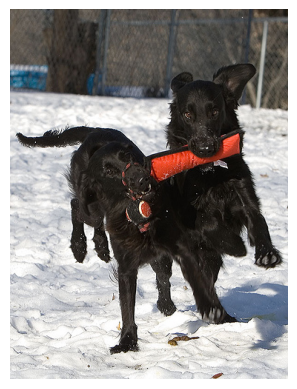

результат: 3154152744_4e93ec8a62.jpg (score: 0.8033)

строка №156
идентификатор описания: 269650644_059a84ece5.jpg#0
текст: A group of people are ice skating in a big city .
изображение соответствующее тексту: 269650644_059a84ece5.jpg
лучшее предсказанное изображение: 3184031654_34b5c4ffe1.jpg


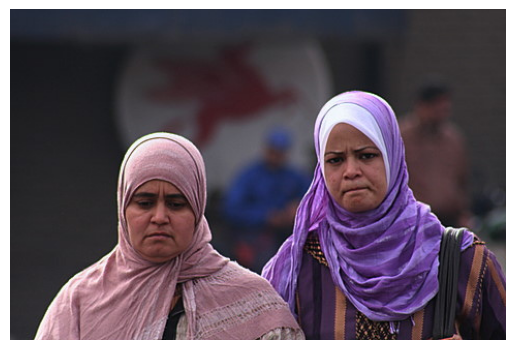

результат: 3184031654_34b5c4ffe1.jpg (score: 0.6177)

строка №105
идентификатор описания: 2428094795_d3a8f46046.jpg#4
текст: Little kid in blue coat and hat riding a tricycle .
изображение соответствующее тексту: 2428094795_d3a8f46046.jpg
This image is unavailable in your country in compliance with local laws


строка №395
идентификатор описания: 3553476195_fb3747d7c1.jpg#4
текст: Two black dogs fighting over an orange toy .
изображение соответствующее тексту: 3553476195_fb3747d7c1.jpg
This image is unavailable in your country in compliance with local laws


строка №378
идентификатор описания: 3514297698_0512623955.jpg#2
текст: A dog jumping for a tennis ball near an ocean
изображение соответствующее тексту: 3514297698_0512623955.jpg
лучшее предсказанное изображение: 3287969199_08e775d896.jpg


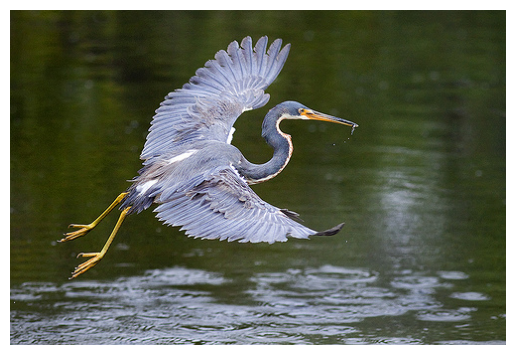

результат: 3287969199_08e775d896.jpg (score: 0.8570)

строка №125
идентификатор описания: 2505056124_1276e8dbcb.jpg#4
текст: Boy flying a distant kite .
изображение соответствующее тексту: 2505056124_1276e8dbcb.jpg
This image is unavailable in your country in compliance with local laws


строка №69
идентификатор описания: 2121140070_a09644550b.jpg#3
текст: kids play ultimate Frisbee .
изображение соответствующее тексту: 2121140070_a09644550b.jpg
This image is unavailable in your country in compliance with local laws


строка №451
идентификатор описания: 607339469_af851c4119.jpg#0
текст: A girl in a purple shirt feeding ducks
изображение соответствующее тексту: 607339469_af851c4119.jpg
This image is unavailable in your country in compliance with local laws




In [113]:
# количество случайных текстов из тетового датасета
n_texts = 10

random_samples = test_dataset.sample(n=n_texts, random_state=RANDOM_STATE)
for idx, row in random_samples.iterrows():
    print(f'строка №{idx+1}')
    print(f'идентификатор описания: {row['query_id']}')
    print(f'текст: \033[1m{row['query_text']}\033[0m')
    print(f"изображение соответствующее тексту: {row['image']}")

    best_image, best_score = test_model(row['query_text'])
    if best_image is not None and best_score is not None:
        print(f'результат: {best_image} (score: {best_score:.4f})\n')
    else:
        print('\n')

### Выводы

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

По результатам теста лучшей модели:
- проведена инициализация лучшей модели (полносвязная нейросеть)
- инициализирован тестовый датасет (таблица `test_dataset` и `test_images `) 
- в тестовых данных 100 уникальных изображений и 500 уникальных текстов
- проведена векторизация тестовых изображений;
- написана функция `test_model` вывода на экран изображения из тестовой выборки на основании текстового описания (для тестирования лучшей модели)
- получаемые, при тестировании модели, изображения не соответствуют текстовому запросу, что свидетельствует о низкой предсказательной способности модели. 
- Для создания сервиса поиска фотографий по текстовому описанию необходимо существенно расширить обучающую выборку и качество разметки, чтобы для разных изображений не было одного и того же текстового описания.


## Выводы

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

**Поставленная задача**\
Представить концепт проекта по поиску референсных изображений на основании тестового описания.

**В процессе работы над проектом:**
1. Была проведена работа по изучению данных:
	- в данных не обнаружено пропусков
	- в тренировочном датасете 1000 уникальных изображений и 977 уникальных тестов


<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

2. Проведена предобработка данных:
- Проведена работа по агрегации оценок экспертов соответствия текста и изображения в датафрейме `expert_annotations` и визуализация полученных результатов
-  По результатам визуализации распределения количества агренированных оценок экспертов установлено, что:
    -  в 57% случаев изображение и запрос совершенно не соответствуют друг другу (оценка 1);
    - в 29% случаев запрос содержит элементы описания изображения, но в целом запрос тексту не соответствует (оценка 2);
    - в 9% случаев запрос и текст соответствуют с точностью до некоторых деталей (оценка 3);
    - в 5% случаев запрос и текст соответствуют полностью (оценка 4).
    - выявленный дисбаланс, вероятно, повлияет на обучение модели в худшую сторону.
- Установлено, что таблице `crowd_annotations` отсутствует 3493 пары *наименование изображения - идентификатор описания* из таблицы `train_dataset`. Основываясь на данном результате выделение целевой переменной будет проведено только исходя из агрегированных оценок экспертов путем присоединения к таблице `train_dataset` данных оценок (таблица `expert_annotations`) на комбинаций вышеуказанных пар (что может улучшить качество обучения, т.к оценки экспертов более точные нежели краудсорсинговые).
- Проведено преобразование значений присоединенных оценок в диапазон от о до 1 путем минимаксной нормализации.
- В результате получена таблица `train_dataset_combined` со следующими столбцами:
- имя файла изображения;
- идентификатор описания;
- текст описания;
- целевая переменная.


<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

3. Проведена подготовка данных для модели МО по результатам которой:
- проведена очистка данных, в соответствии с юридическими ограничениями:
	- проведена очистка данных с использованием регулярных выражений
    - из таблицы `train_dataset_combined` исключено 1806 строк, содержащих описание и наименование изображений детей (ребёнком считается любой человек, не достигший 16-ти лет);
	- в результате получен очищенный датафрейм `train_dataset_filtered`, не содержащий дубликатов.
- проведена векторизация текстов с использованием модели BERT-base:
	- инициализирован токенизатор;
    - тесты преобразованы в номера токенов (векторы токенов);
    - получившиеся вектора преобразованы в эмбеддинги.
- проведена векторизация изображений с использованием предобученной модели ResNet50:
	- проведена загрузка изображений с использованием библиотеки PIL;
	- перед преобразованием изображений в эмбеддинги проведена их предобработка для использования модели обученной на датасете  ImageNet.
- по результатам векторизации текстов и изображений получены эмбеддинги с размерностью:
	- (4503, 768) для тестовых эмбеддингов (4503 - количество пар текст-изображение в `train_dataset_filtered`, 768 - размерность текстовых векторов);
	- (4503, 2048) для эмбеддингов изображений (4503 - количество пар текст-изображение в `train_dataset_filtered`, 2048 – размер визуальных векторов, выход с последнего сверточного слоя ResNet50).
- проведено разделение данных на тренировочную и валидационную выборки в соотношении 90:10. Данные разделены так чтобы уникальные query_id не попадали сразу в две выборки.


<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

4. Проведено обучение моделей МО с различными гиперпараметрами:
- написана функция `objective` по подбору гиперпараметров для моделей:
	- подбор лучших гиперпараметров проведен на основании значения метрики MSE при кроссвалидации с помощью библиотеки optuna;
	- в качестве моделей выбраны: Ridge, Lasso, ElasticNet, LinearRegression и полносвязная нейросеть
- для обучения нейросети написан класс `FeedForwardNN` и функция `training`
- по результатам обучения моделей лушее значение метрики MSE при кроссвалидации показала полносвязная нейросеть (0.059) (параметры выведены ниже).


In [114]:
# лучшие параметры нейросети
params_nn

,parameter,value
0,n_layers,1
1,hidden_size,803
2,dropout,0.3245
3,batch_size,64
4,learning_rate,0.0004
5,optimizer,adam
6,weight_decay,0.0005
7,epochs,371


<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

5. Проведено тестирование лучшей модели:
- проведена инициализация лучшей модели (полносвязная нейросеть)
- инициализирован тестовый датасет (таблица `test_dataset` и `test_images `) 
- в тестовых данных 100 уникальных изображений и 500 уникальных текстов
- проведена векторизация тестовых изображений;
- написана функция `test_model` вывода на экран изображения из тестовой выборки на основании текстового описания (для тестирования лучшей модели)
- получаемые, при тестировании модели, изображения не соответствуют текстовому запросу, что свидетельствует о низкой предсказательной способности модели. 
- Для создания сервиса поиска фотографий по текстовому описанию необходимо существенно расширить обучающую выборку и качество разметки, чтобы для разных изображений не было одного и того же текстового описания. Возможно для векторизации изображений необходимо использовать другие модели (с иной предобработкой изображений, нежели требуется для ResNet)
